# Simulación de un péndulo invertido en MuJoCo con control por ubicación de polos

## Tutorial detallado paso a paso

**Sistema:** carro–péndulo invertido  
**Control:** realimentación de estados por *pole placement*  
**Simulación:** MuJoCo + Python  

---

## Objetivo

Construir desde cero una demo en MuJoCo de un péndulo invertido sobre un carro y comparar:

1. La respuesta **sin control**.
2. La respuesta **controlada** con ubicación de polos.

El flujo completo será:

$$
\text{modelo físico} \rightarrow \text{modelo linealizado} \rightarrow \text{pole placement} \rightarrow \text{simulación en MuJoCo}
$$

Al final se grafican ambas señales: estados sin controlar, estados controlados y acción de control.

# 1. Instalación en Google Colab

MuJoCo requiere un backend de renderizado. En Colab usaremos `EGL` para renderizar video sin ventana gráfica.

In [1]:
!apt-get -qq update
!apt-get -qq install -y libegl1 libgl1-mesa-dev libglfw3 ffmpeg > /dev/null
!pip -q install mujoco mediapy scipy

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 129.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 151.4 MB/s eta 0:00:00


# 2. Importar librerías

In [2]:
import os
os.environ["MUJOCO_GL"] = "egl"

from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import mujoco
import mediapy as media

from scipy.signal import place_poles

np.set_printoptions(precision=5, suppress=True)
plt.rcParams["figure.figsize"] = (11, 4)

print("MuJoCo version:", mujoco.mj_versionString())

MuJoCo version: 3.9.0


# 3. Modelo físico del péndulo invertido

Consideramos un carro de masa $M$ que se mueve horizontalmente y un péndulo de masa $m$ articulado al carro.

Las coordenadas son:

$$
q = \begin{bmatrix}x \\ \theta\end{bmatrix}
$$

con:

- $x$: posición horizontal del carro.
- $\theta$: ángulo del péndulo respecto a la vertical invertida.

El estado de control será:

$$
\mathbf{x}=
\begin{bmatrix}
x \\
\dot{x} \\
\theta \\
\dot{\theta}
\end{bmatrix}
$$

La entrada de control es una fuerza horizontal aplicada al carro:

$$
u = F
$$

El objetivo es estabilizar:

$$
\mathbf{x}=0
$$

que corresponde a carro centrado y péndulo vertical hacia arriba.

# 4. Modelo linealizado para diseño del controlador

Alrededor del equilibrio vertical invertido:

$$
x=0, \quad \dot{x}=0, \quad \theta=0, \quad \dot{\theta}=0
$$

una forma linealizada clásica del carro–péndulo es:

$$
\dot{\mathbf{x}} = A\mathbf{x}+Bu
$$

con:

$$
A =
\begin{bmatrix}
0 & 1 & 0 & 0\\
0 & 0 & -\frac{mg}{M} & 0\\
0 & 0 & 0 & 1\\
0 & 0 & \frac{(M+m)g}{Ml} & 0
\end{bmatrix}
$$

$$
B =
\begin{bmatrix}
0\\
\frac{1}{M}\\
0\\
-\frac{1}{Ml}
\end{bmatrix}
$$

La ley de control será:

$$
u=-K\mathbf{x}
$$

y el sistema en lazo cerrado:

$$
\dot{\mathbf{x}}=(A-BK)\mathbf{x}
$$

El método de ubicación de polos selecciona $K$ para que los autovalores de $A-BK$ queden en posiciones deseadas.

In [3]:
@dataclass
class CartPoleParams:
    M: float = 1.0
    m: float = 0.2
    l: float = 0.5
    g: float = 9.81
    dt: float = 0.002
    force_limit: float = 100.0

params = CartPoleParams()
print(params)

CartPoleParams(M=1.0, m=0.2, l=0.5, g=9.81, dt=0.002, force_limit=100.0)


# 5. Crear el modelo MJCF/XML de MuJoCo

El modelo tendrá:

- un carro con una articulación `slide` en $x$,
- un péndulo con una articulación `hinge`,
- un actuador `motor` que aplica fuerza horizontal sobre el carro.

Para que $\theta=0$ represente la vertical invertida, dibujamos el péndulo hacia arriba desde el pivote.

## Construcción del modelo geométrico del péndulo invertido en MuJoCo

En esta celda se construye programáticamente el archivo **MJCF/XML** que describe la geometría, las masas, las articulaciones y el actuador del sistema carro–péndulo invertido.

El objetivo es pasar de una descripción física del sistema a una representación compatible con MuJoCo.

---

### 1. Relación entre la geometría física y el modelo MJCF

El sistema está compuesto por:

1. Un **carro** que se desplaza horizontalmente.
2. Un **péndulo rígido** unido al carro mediante una articulación rotacional.
3. Un **actuador horizontal** que aplica una fuerza sobre el carro.

La coordenada generalizada del carro es:

\[
x
\]

y la coordenada angular del péndulo es:

\[
\theta
\]

En MuJoCo estas coordenadas se implementan con dos articulaciones:

```xml
<joint name="cart_slide" type="slide" axis="1 0 0"/>

In [5]:
L = 2.0 * params.l
I_pend = (1/12) * params.m * L**2

mjcf = f"""
<mujoco model="cartpole_inverted">
    <compiler angle="radian" inertiafromgeom="false"/>
    <option timestep="{params.dt}" gravity="0 0 -{params.g}" integrator="RK4"/>
    <visual><global offwidth="640" offheight="480"/></visual>
    <default>
        <joint damping="0.02" armature="0.0"/>
        <geom rgba="0.7 0.7 0.7 1"/>
    </default>
    <worldbody>
        <light pos="0 0 4" dir="0 0 -1"/>
        <geom name="floor" type="plane" pos="0 0 0" size="4 2 0.1" rgba="0.9 0.9 0.9 1"/>
        <geom name="rail" type="box" pos="0 0 0.05" size="2.5 0.03 0.03" rgba="0.2 0.2 0.2 1"/>
        <body name="cart" pos="0 0 0.25">
            <joint name="cart_slide" type="slide" axis="1 0 0" limited="true" range="-2.2 2.2"/>
            <inertial pos="0 0 0" mass="{params.M}" diaginertia="0.02 0.02 0.02"/>
            <geom name="cart_geom" type="box" size="0.18 0.10 0.08" rgba="0.1 0.3 0.8 1"/>
            <geom name="pivot" type="sphere" pos="0 0 0.09" size="0.04" rgba="0.05 0.05 0.05 1"/>
            <body name="pole" pos="0 0 0.09">
                <joint name="pole_hinge" type="hinge" axis="0 1 0" limited="false"/>
                <inertial pos="0 0 {params.l}" mass="{params.m}" diaginertia="{I_pend} {I_pend} {I_pend}"/>
                <geom name="pole_geom" type="capsule" fromto="0 0 0 0 0 {L}" size="0.025" rgba="0.8 0.2 0.1 1"/>
                <geom name="tip" type="sphere" pos="0 0 {L}" size="0.045" rgba="0.1 0.1 0.1 1"/>
            </body>
        </body>
    </worldbody>
    <actuator>
        <motor name="cart_force" joint="cart_slide" gear="1" ctrllimited="true" ctrlrange="-{params.force_limit} {params.force_limit}"/>
    </actuator>
</mujoco>
"""

xml_path = Path("/content/cartpole_inverted.xml")
xml_path.write_text(mjcf)
print("XML guardado en:", xml_path)

XML guardado en: /content/cartpole_inverted.xml


# 6. Cargar el modelo e inspeccionar variables internas

MuJoCo almacena:

$$
qpos=[x,\theta]
$$

$$
qvel=[\dot{x},\dot{\theta}]
$$

pero el controlador usa:

$$
x_{control}=[x,\dot{x},\theta,\dot{\theta}]^T
$$

In [6]:
model = mujoco.MjModel.from_xml_path(str(xml_path))
data = mujoco.MjData(model)

print("nq =", model.nq)
print("nv =", model.nv)
print("nu =", model.nu)

for j in range(model.njnt):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, j)
    print(j, name, "qpos adr:", model.jnt_qposadr[j], "qvel adr:", model.jnt_dofadr[j])

for a in range(model.nu):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, a)
    print("actuator", a, name)

nq = 2
nv = 2
nu = 1
0 cart_slide qpos adr: 0 qvel adr: 0
1 pole_hinge qpos adr: 1 qvel adr: 1
actuator 0 cart_force


In [7]:
cart_joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "cart_slide")
pole_joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "pole_hinge")
actuator_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "cart_force")

x_qpos_id = int(model.jnt_qposadr[cart_joint_id])
theta_qpos_id = int(model.jnt_qposadr[pole_joint_id])
x_qvel_id = int(model.jnt_dofadr[cart_joint_id])
theta_qvel_id = int(model.jnt_dofadr[pole_joint_id])

print("x qpos id:", x_qpos_id)
print("theta qpos id:", theta_qpos_id)
print("xdot qvel id:", x_qvel_id)
print("thetadot qvel id:", theta_qvel_id)
print("actuator id:", actuator_id)

x qpos id: 0
theta qpos id: 1
xdot qvel id: 0
thetadot qvel id: 1
actuator id: 0


# 7. Construir matrices $A$ y $B$

In [8]:
M, m, l, g = params.M, params.m, params.l, params.g

A = np.array([
    [0, 1, 0, 0],
    [0, 0, -m*g/M, 0],
    [0, 0, 0, 1],
    [0, 0, (M+m)*g/(M*l), 0]
], dtype=float)

B = np.array([
    [0],
    [1/M],
    [0],
    [-1/(M*l)]
], dtype=float)

print("A =")
print(A)
print("B =")
print(B)
print("Autovalores lazo abierto:", np.linalg.eigvals(A))

A =
[[ 0.     1.     0.     0.   ]
 [ 0.     0.    -1.962  0.   ]
 [ 0.     0.     0.     1.   ]
 [ 0.     0.    23.544  0.   ]]
B =
[[ 0.]
 [ 1.]
 [ 0.]
 [-2.]]
Autovalores lazo abierto: [ 0.       0.       4.85222 -4.85222]


# 8. Verificar controlabilidad

La matriz de controlabilidad es:

$$
\mathcal{C}=[B\ AB\ A^2B\ A^3B]
$$

El sistema es controlable si:

$$
\mathrm{rank}(\mathcal{C})=4
$$

In [9]:
Ctrb = np.hstack([B, A@B, A@A@B, A@A@A@B])
print("Matriz de controlabilidad:")
print(Ctrb)
print("Rango:", np.linalg.matrix_rank(Ctrb))

Matriz de controlabilidad:
[[  0.      1.      0.      3.924]
 [  1.      0.      3.924   0.   ]
 [  0.     -2.      0.    -47.088]
 [ -2.      0.    -47.088   0.   ]]
Rango: 4


# 9. Diseño del controlador por ubicación de polos

Escogemos polos reales negativos:

$$
p=
\{-2.5,-3.0,-3.5,-4.0\}
$$

Estos polos producen una respuesta estable y moderadamente rápida.

In [10]:
desired_poles = np.array([-2.5, -3.0, -3.5, -4.0])
K = place_poles(A, B, desired_poles).gain_matrix
A_cl = A - B @ K

print("K =")
print(K)
print("Polos de A-BK:")
print(np.linalg.eigvals(A_cl))

K =
[[ -5.35168  -6.79154 -45.82284  -9.89577]]
Polos de A-BK:
[-4.  -3.5 -3.  -2.5]


# 10. Funciones auxiliares para simular en MuJoCo

En cada paso de simulación:

1. Leer `qpos` y `qvel`.
2. Construir:
   $$
   x=[x,\dot{x},\theta,\dot{\theta}]^T
   $$
3. Calcular:
   $$
   u=-Kx
   $$
4. Escribir `data.ctrl[0]=u`.
5. Avanzar con `mujoco.mj_step`.

In [11]:
def wrap_angle(angle):
    return (angle + np.pi) % (2*np.pi) - np.pi


def get_control_state(data):
    x = data.qpos[x_qpos_id]
    theta = wrap_angle(data.qpos[theta_qpos_id])
    xdot = data.qvel[x_qvel_id]
    thetadot = data.qvel[theta_qvel_id]
    return np.array([x, xdot, theta, thetadot], dtype=float)


def set_initial_state(data, x0=0.0, theta0=0.1, xdot0=0.0, thetadot0=0.0):
    data.qpos[:] = 0.0
    data.qvel[:] = 0.0
    data.qpos[x_qpos_id] = x0
    data.qpos[theta_qpos_id] = theta0
    data.qvel[x_qvel_id] = xdot0
    data.qvel[theta_qvel_id] = thetadot0
    mujoco.mj_forward(model, data)

# 11. Función de simulación: sin control y con control

La función recibe `controlled=True` o `False`.

- Sin control:
  $$
  u=0
  $$

- Con control:
  $$
  u=-Kx
  $$

In [12]:
def simulate_cartpole(controlled=True, T=6.0, theta0_deg=8.0, render=False, fps=30):
    data_sim = mujoco.MjData(model)
    set_initial_state(data_sim, theta0=np.deg2rad(theta0_deg))

    dt = params.dt
    n_steps = int(T / dt)
    time = np.arange(n_steps) * dt
    state_hist = np.zeros((n_steps, 4))
    u_hist = np.zeros(n_steps)

    frames = []
    renderer = None
    render_every = max(1, int(round(1.0 / (fps * dt))))

    if render:
        renderer = mujoco.Renderer(model, width=640, height=480)
        camera = mujoco.MjvCamera()
        camera.azimuth = 90
        camera.elevation = -12
        camera.distance = 3.5
        camera.lookat[:] = np.array([0.0, 0.0, 0.7])

    for k in range(n_steps):
        x_state = get_control_state(data_sim)

        if controlled:
            u = float(-(K @ x_state.reshape(-1, 1))[0, 0])
            u = np.clip(u, -params.force_limit, params.force_limit)
        else:
            u = 0.0

        data_sim.ctrl[actuator_id] = u
        state_hist[k] = x_state
        u_hist[k] = u

        mujoco.mj_step(model, data_sim)

        if render and (k % render_every == 0):
            renderer.update_scene(data_sim, camera=camera)
            frames.append(renderer.render())

    if renderer is not None:
        renderer.close()

    return {"time": time, "state": state_hist, "u": u_hist}, frames

# 12. Simulación sin control

Usamos una pequeña perturbación inicial:

$$
\theta(0)=8^\circ
$$

El péndulo debería caer porque el equilibrio invertido es inestable.

In [13]:
results_uncontrolled, frames_uncontrolled = simulate_cartpole(
    controlled=False,
    T=6.0,
    theta0_deg=8.0,
    render=True,
    fps=30
)

print("Simulación sin control finalizada.")
print("Frames:", len(frames_uncontrolled))

Simulación sin control finalizada.
Frames: 177


In [14]:
media.show_video(frames_uncontrolled, fps=30)

This browser does not support the video tag.


# 13. Simulación controlada con pole placement

Ahora aplicamos:

$$
u=-Kx
$$

con la misma condición inicial.

In [15]:
results_controlled, frames_controlled = simulate_cartpole(
    controlled=True,
    T=6.0,
    theta0_deg=8.0,
    render=True,
    fps=30
)

print("Simulación controlada finalizada.")
print("Frames:", len(frames_controlled))

Simulación controlada finalizada.
Frames: 177


In [16]:
media.show_video(frames_controlled, fps=30)

This browser does not support the video tag.


# 14. Comparar señales sin control y controladas

In [17]:
t = results_controlled["time"]

x_unc = results_uncontrolled["state"][:, 0]
xdot_unc = results_uncontrolled["state"][:, 1]
theta_unc = results_uncontrolled["state"][:, 2]
thetadot_unc = results_uncontrolled["state"][:, 3]
u_unc = results_uncontrolled["u"]

x_ctl = results_controlled["state"][:, 0]
xdot_ctl = results_controlled["state"][:, 1]
theta_ctl = results_controlled["state"][:, 2]
thetadot_ctl = results_controlled["state"][:, 3]
u_ctl = results_controlled["u"]

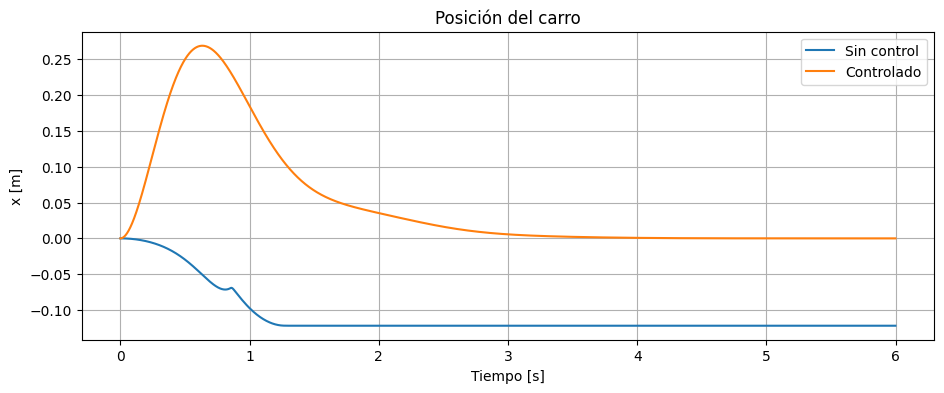

In [18]:
plt.figure()
plt.plot(t, x_unc, label="Sin control")
plt.plot(t, x_ctl, label="Controlado")
plt.xlabel("Tiempo [s]")
plt.ylabel("x [m]")
plt.title("Posición del carro")
plt.grid(True)
plt.legend()
plt.show()

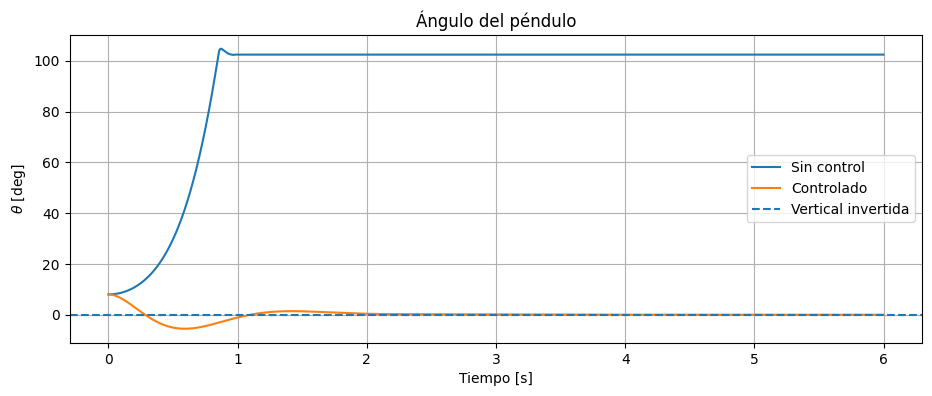

In [19]:
plt.figure()
plt.plot(t, np.rad2deg(theta_unc), label="Sin control")
plt.plot(t, np.rad2deg(theta_ctl), label="Controlado")
plt.axhline(0, linestyle="--", label="Vertical invertida")
plt.xlabel("Tiempo [s]")
plt.ylabel(r"$\theta$ [deg]")
plt.title("Ángulo del péndulo")
plt.grid(True)
plt.legend()
plt.show()

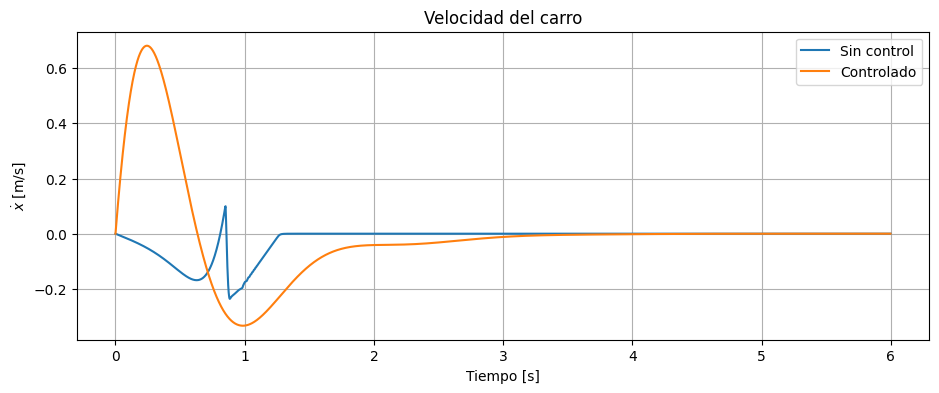

In [20]:
plt.figure()
plt.plot(t, xdot_unc, label="Sin control")
plt.plot(t, xdot_ctl, label="Controlado")
plt.xlabel("Tiempo [s]")
plt.ylabel(r"$\dot{x}$ [m/s]")
plt.title("Velocidad del carro")
plt.grid(True)
plt.legend()
plt.show()

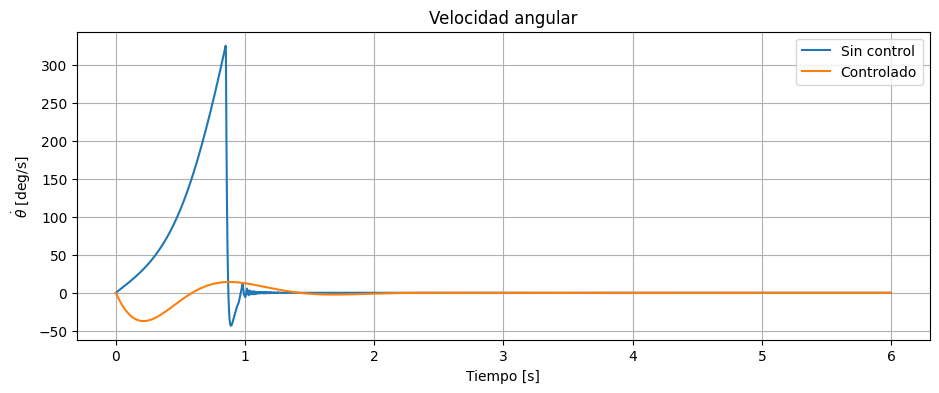

In [21]:
plt.figure()
plt.plot(t, np.rad2deg(thetadot_unc), label="Sin control")
plt.plot(t, np.rad2deg(thetadot_ctl), label="Controlado")
plt.xlabel("Tiempo [s]")
plt.ylabel(r"$\dot{\theta}$ [deg/s]")
plt.title("Velocidad angular")
plt.grid(True)
plt.legend()
plt.show()

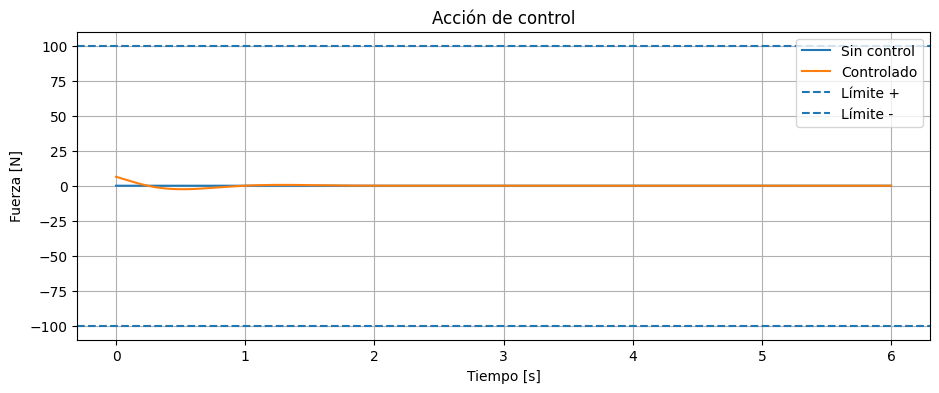

In [22]:
plt.figure()
plt.plot(t, u_unc, label="Sin control")
plt.plot(t, u_ctl, label="Controlado")
plt.axhline(params.force_limit, linestyle="--", label="Límite +")
plt.axhline(-params.force_limit, linestyle="--", label="Límite -")
plt.xlabel("Tiempo [s]")
plt.ylabel("Fuerza [N]")
plt.title("Acción de control")
plt.grid(True)
plt.legend()
plt.show()

# 15. Métricas de desempeño

Calculamos:

$$
\mathrm{RMS}_\theta = \sqrt{\frac{1}{N}\sum_{k=1}^{N}\theta[k]^2}
$$

$$
\mathrm{RMS}_u = \sqrt{\frac{1}{N}\sum_{k=1}^{N}u[k]^2}
$$

In [23]:
def rms(signal):
    return np.sqrt(np.mean(signal**2))

print("RMS theta sin control [deg]:", rms(np.rad2deg(theta_unc)))
print("RMS theta controlado [deg]:", rms(np.rad2deg(theta_ctl)))
print("Max theta sin control [deg]:", np.max(np.abs(np.rad2deg(theta_unc))))
print("Max theta controlado [deg]:", np.max(np.abs(np.rad2deg(theta_ctl))))
print("RMS u sin control [N]:", rms(u_unc))
print("RMS u controlado [N]:", rms(u_ctl))

RMS theta sin control [deg]: 96.21919010350726
RMS theta controlado [deg]: 1.8588620814822159
Max theta sin control [deg]: 104.73677871572198
Max theta controlado [deg]: 8.00000000000001
RMS u sin control [N]: 0.0
RMS u controlado [N]: 0.9607005023201863


# 16. Interpretación

## Sistema sin control

Con:

$$
u=0
$$

el equilibrio vertical invertido es inestable. Una pequeña perturbación angular hace que el péndulo caiga.

## Sistema controlado

Con:

$$
u=-Kx
$$

los polos de lazo cerrado son los especificados:

$$
\lambda(A-BK)=\{-2.5,-3.0,-3.5,-4.0\}
$$

Por tanto, para perturbaciones pequeñas, el ángulo vuelve a cero y el carro se mantiene cerca del origen.

---

# 17. Actividades sugeridas

1. Cambiar los polos a:
   ```python
   [-1.5, -2.0, -2.5, -3.0]
   ```
   y comparar la rapidez de respuesta.

2. Cambiar los polos a:
   ```python
   [-4.0, -5.0, -6.0, -7.0]
   ```
   y observar el aumento en la acción de control.

3. Probar condiciones iniciales:
   $$
   \theta(0)=5^\circ,10^\circ,15^\circ,25^\circ
   $$

4. Cambiar el límite de fuerza `force_limit` y analizar saturación.

5. Comparar este método con LQR.

# 18. Resumen final

En este notebook se construyó una simulación completa de un péndulo invertido en MuJoCo controlado por ubicación de polos.

Se realizó:

1. Creación del modelo MJCF.
2. Definición del modelo linealizado.
3. Verificación de controlabilidad.
4. Diseño del controlador:
   $$
   u=-Kx
   $$
5. Simulación sin control.
6. Simulación controlada.
7. Comparación de señales y acción de control.

Este flujo puede extenderse a sistemas más complejos como brazos robóticos, péndulos dobles, robots móviles y exoesqueletos.